In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)



Saving DailyDelhiClimateTest.csv to DailyDelhiClimateTest.csv


In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_train = pd.read_csv(filename)

Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain.csv


In [ ]:
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
...,...,...,...,...,...
109,2017-04-20,34.500000,27.500000,5.562500,998.625000
110,2017-04-21,34.250000,39.375000,6.962500,999.875000
111,2017-04-22,32.900000,40.900000,8.890000,1001.600000
112,2017-04-23,32.875000,27.500000,9.962500,1002.125000


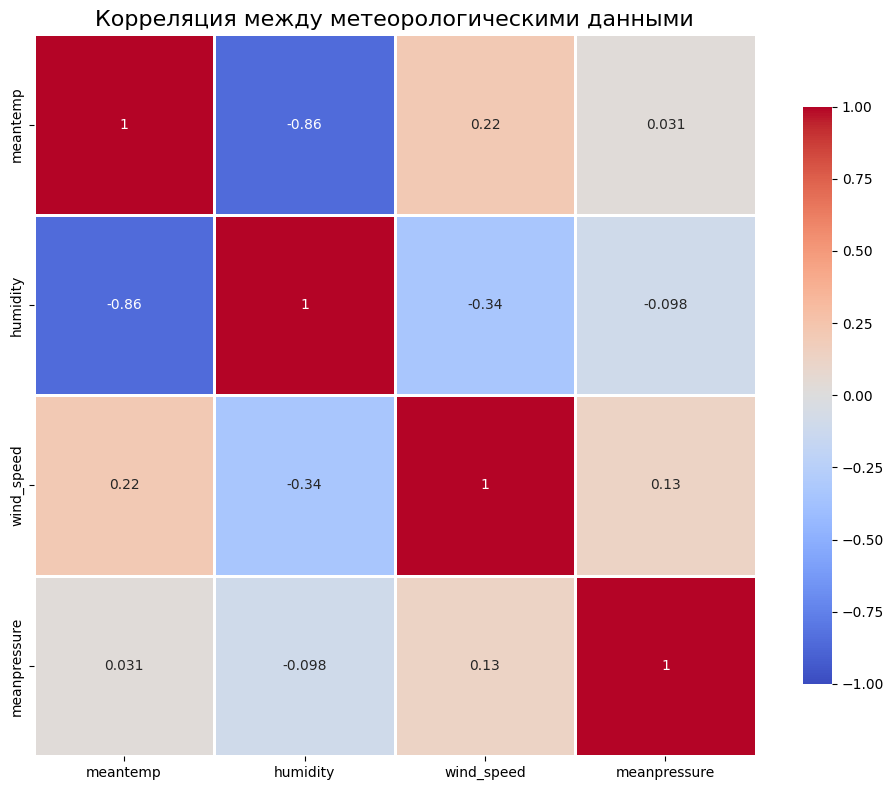

In [ ]:
heatmap_matrix = df[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Корреляция между метеорологическими данными', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')

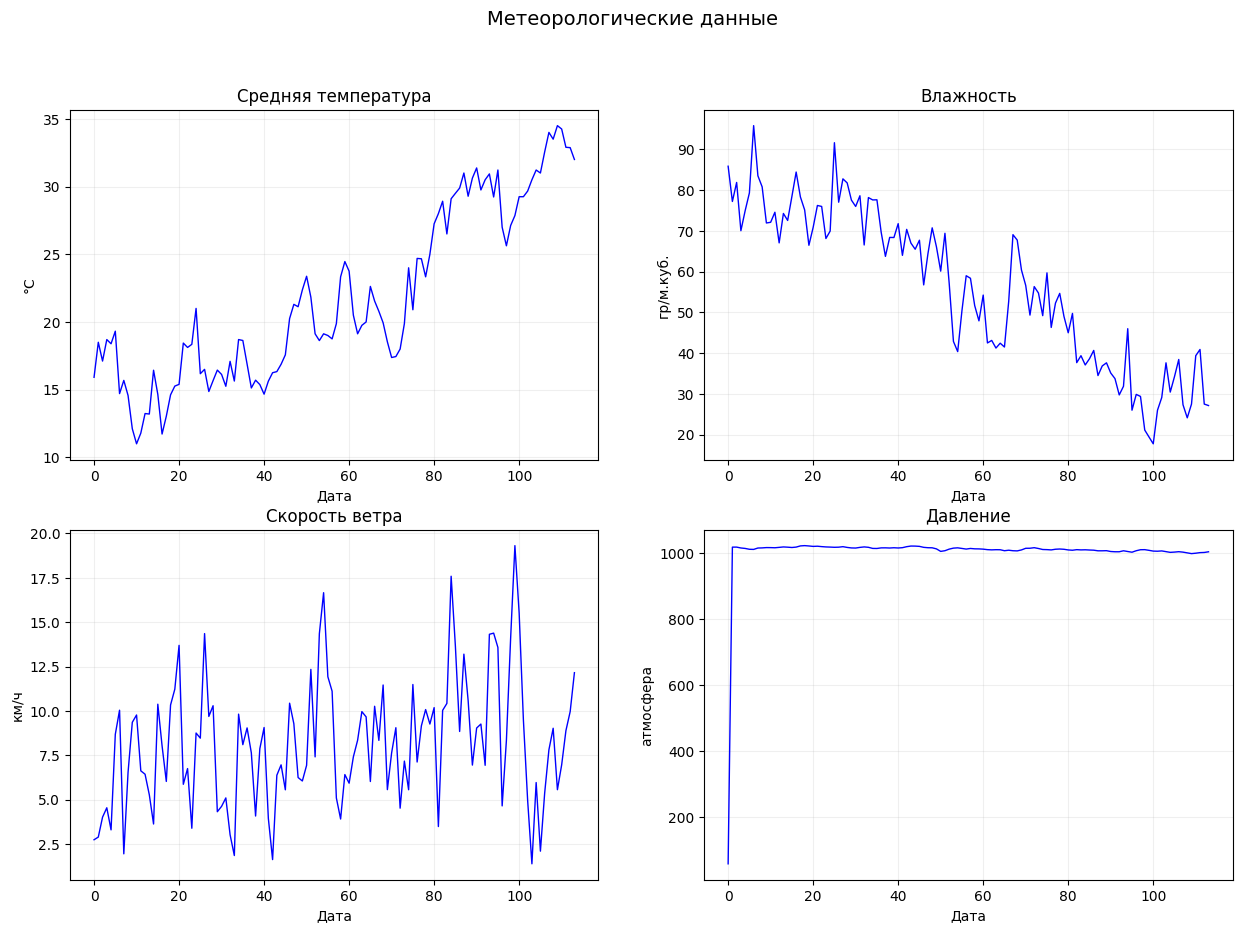

In [ ]:
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Метеорологические данные', fontsize=14)

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

axes[0, 0].plot(df.index, df['meantemp'], color='blue', linewidth=1)
axes[0, 0].set_title('Средняя температура')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('°С')
axes[0, 0].grid(True, alpha=0.2)

axes[0, 1].plot(df.index, df['humidity'], color='blue', linewidth=1)
axes[0, 1].set_title('Влажность')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('гр/м.куб.')
axes[0, 1].grid(True, alpha=0.2)


axes[1, 0].plot(df.index, df['wind_speed'], color='blue', linewidth=1)
axes[1, 0].set_title('Скорость ветра')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('км/ч')
axes[1, 0].grid(True, alpha=0.2)

axes[1, 1].plot(df.index, df['meanpressure'], color='blue', linewidth=1)
axes[1, 1].set_title('Давление')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('атмосфера')
axes[1, 1].grid(True, alpha=0.2)

In [ ]:
df['Days'] = df['date'].dt.day    #колонка дня

In [ ]:
df['Month'] = df['date'].dt.month #месяца

In [ ]:
df['Year'] = df['date'].dt.year #года

In [ ]:
df = df.drop(columns = 'date')

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

In [ ]:
import statsmodels.api as sm
from scipy import stats
from scipy.special import inv_boxcox
import itertools


In [ ]:
ts = df['meantemp']

In [ ]:
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] > 0.05:
    print("Series is non stationary; differencing is needed.")
else:
    print("Series is stationary; no differencing needed.")

ADF Statistic: -1.096474
p-value: 0.716476
Series is non stationary; differencing is needed.


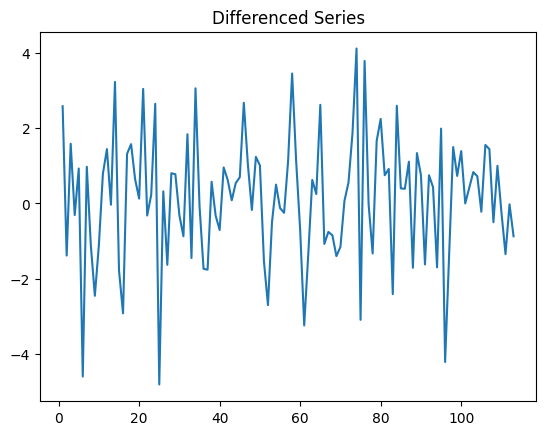

ADF Statistic (differenced): -12.035798
p-value (differenced): 0.000000


In [ ]:
ts_diff = ts.diff().dropna()

ts_diff.plot(title='Differenced Series')
plt.show()

result_diff = adfuller(ts_diff)
print('ADF Statistic (differenced): %f' % result_diff[0])
print('p-value (differenced): %f' % result_diff[1])

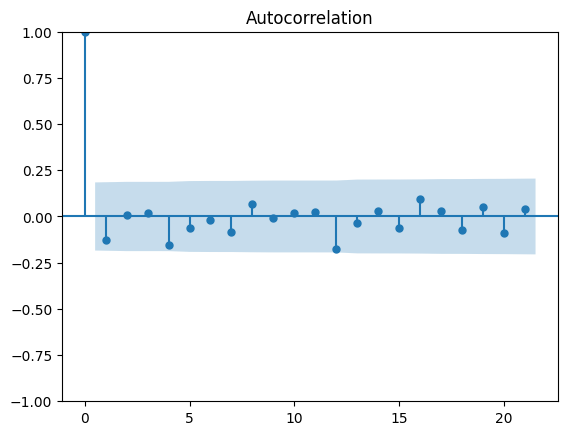

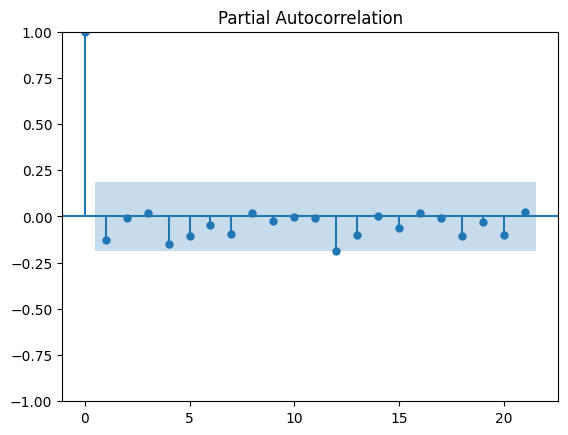

In [ ]:
plot_acf(ts_diff)
plt.show()

plot_pacf(ts_diff)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
p = range(0, 10)
d = range(0, 10)
q = range(0, 10)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(ts, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.p

Best ARIMA order: (3, 6, 3) with AIC: 14.0


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(ts, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Best ARIMA order: (0, 1, 0) with AIC: 441.2600773080422


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.5 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

model = auto_arima(ts,
                   start_p=0, max_p=5,
                   start_d=0, max_d=2,
                   start_q=0, max_q=5,
                   seasonal=False,
                   trace=True,
                   error_action='ignore',
                   suppress_warnings=True,
                   stepwise=True)
print(f'Best ARIMA order: {model.order} with AIC: {model.aic()}')


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=442.455, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=442.546, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=442.540, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=441.260, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=444.537, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.128 seconds
Best ARIMA order: (0, 1, 0) with AIC: 441.2600773080422


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

p, d, q = best_order

P = range(0, 3)
D = range(0, 2)
Q = range(0, 3)
s = 12

best_sarima_aic = np.inf
best_sarima_order = None
best_sarima_model = None

for P_val in P:
    for D_val in D:
        for Q_val in Q:
            seasonal_order = (P_val, D_val, Q_val, s)
            try:
                model = SARIMAX(ts,
                               order=(p, d, q),
                               seasonal_order=seasonal_order,
                               enforce_stationarity=False,
                               enforce_invertibility=False)
                results = model.fit(disp=False)

                if results.aic < best_sarima_aic:
                    best_sarima_aic = results.aic
                    best_sarima_order = seasonal_order
                    best_sarima_model = results
                    print(f'SARIMA{p,d,q}x{seasonal_order} AIC: {results.aic:.2f}')
            except:
                continue

print(f'\nBest SARIMA: ARIMA{best_order}x{best_sarima_order} with AIC:{best_sarima_aic:.2f}')


Best SARIMA: ARIMA(0, 1, 0)xNone with AIC:inf


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

available_vars = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

df_model = df[available_vars].copy()
print(f"\nData shape: {df_model.shape}")


Data shape: (114, 4)


In [ ]:
df_diff = df_model.copy() #stationary
diff_orders = {}

for var in available_vars:
    series = df_model[var].dropna()
    result = adfuller(series)

    print(f"\n{var}: p-value: {result[1]:.6f}")

    if result[1] <= 0.05:
        print(f"  = Stationary")
        diff_orders[var] = 0
    else:
        print(f"  = Non-stationary")
        df_diff[var] = df_model[var].diff()
        diff_orders[var] = 1

        result_diff = adfuller(df_diff[var].dropna())
        print(f"  After differencing p-value: {result_diff[1]:.6f}")

df_diff = df_diff.dropna()
print(f"\nData after differencing shape: {df_diff.shape}")


meantemp: p-value: 0.716476
  = Non-stationary
  After differencing p-value: 0.000000

humidity: p-value: 0.852937
  = Non-stationary
  After differencing p-value: 0.000000

wind_speed: p-value: 0.000000
  = Stationary

meanpressure: p-value: 0.212762
  = Non-stationary
  After differencing p-value: 0.000000

Data after differencing shape: (113, 4)


In [ ]:
scaler_dict = {} #normalization
df_scaled = pd.DataFrame(index=df_diff.index)

for var in available_vars:
    scaler = StandardScaler()
    values = df_diff[var].values.reshape(-1, 1)
    df_scaled[var] = scaler.fit_transform(values).flatten()
    scaler_dict[var] = scaler
    print(f"{var}: mean={scaler.mean_[0]:.4f}, std={scaler.scale_[0]:.4f}")

meantemp: mean=0.1424, std=1.6839
humidity: mean=-0.5197, std=7.4234
wind_speed: mean=8.1917, std=3.5516
meanpressure: mean=8.3641, std=89.8734


In [ ]:
print(f"\nScaled data shape: {df_scaled.shape}")


Scaled data shape: (113, 4)


In [ ]:
n_obs = len(df_scaled)
n_vars = len(available_vars)

if n_obs > n_vars + 2:
    max_lags = min(5, (n_obs // (n_vars + 1)) - 1)
    print(f"Max lags to test: {max_lags}")

    if max_lags >= 1:
        var_model = VAR(df_scaled)
        lag_order = var_model.select_order(maxlags=max_lags)

        optimal_lags = lag_order.selected_orders['aic']
        if optimal_lags == 0:
            optimal_lags = 1

        print(f"\nOptimal lags: {optimal_lags}")

        var_fitted = var_model.fit(optimal_lags)
        forecast_steps = min(20, len(df) // 10)
        last_obs = df_scaled.values[-optimal_lags:]
        forecast_scaled = var_fitted.forecast(y=last_obs, steps=forecast_steps)

Max lags to test: 5

Optimal lags: 2


In [ ]:
print(f"Forecast scaled shape: {forecast_scaled.shape}")

Forecast scaled shape: (11, 4)


In [ ]:
print(f"Forecast scaled sample (first 3 steps):\n{forecast_scaled[:3]}")

Forecast scaled sample (first 3 steps):
[[ 0.09462054  0.19606351  0.93368386 -0.09169485]
 [ 0.16095183  0.07802217  0.49977428 -0.09359712]
 [ 0.03898528  0.03137482  0.16099647 -0.09365197]]


In [ ]:
forecast_original = np.zeros((forecast_steps, len(available_vars)))
for i, var in enumerate(available_vars):
      print(f"\n{var}:")

      forecast_scaled_reconstructed = forecast_scaled[:, i]
      forecast_normalized = scaler_dict[var].inverse_transform(
          forecast_scaled_reconstructed.reshape(-1, 1)
      ).flatten()

      print(f"After inverse normalization: range [{forecast_normalized.min():.4f}, {forecast_normalized.max():.4f}]")



meantemp:
After inverse normalization: range [0.1257, 0.4134]

humidity:
After inverse normalization: range [-0.5003, 0.9358]

wind_speed:
After inverse normalization: range [8.3037, 11.5078]

meanpressure:
After inverse normalization: range [-0.0957, 0.1232]


In [ ]:
if diff_orders[var] == 1:
    last_original = df_model[var].iloc[-1]
    forecast_original[:, i] = np.cumsum(forecast_normalized) + last_original
    print(f"After inverse differencing (last value: {last_original:.4f})")
else:
    forecast_original[:, i] = forecast_normalized
    print(f"No differencing to reverse")

print(f"Final range: [{forecast_original[:, i].min():.2f}, {forecast_original[:, i].max():.2f}]")


After inverse differencing (last value: 1004.1429)
Final range: [1003.50, 1004.27]


In [ ]:
forecast_index = np.arange(len(df), len(df) + forecast_steps)
forecast_df = pd.DataFrame(
    forecast_original,
    index=forecast_index,
    columns=available_vars
    )

forecast_df['meanpressure'] = forecast_df['meanpressure'].clip(lower=980, upper=1030)
forecast_df['humidity'] = forecast_df['humidity'].clip(lower=0, upper=100)
forecast_df['wind_speed'] = forecast_df['wind_speed'].clip(lower=0)
forecast_df['meantemp'] = forecast_df['meantemp'].clip(lower=-10, upper=45)


for var in available_vars:
    last_historical = df[var].iloc[-1]
    forecast_values = forecast_df[var].values

    print(f"\n{var}:")
    print(f"  Last historical: {last_historical:.4f}")
    print(f"  Forecast next: {forecast_values[0]:.4f} (change: {forecast_values[0] - last_historical:.4f})")
    print(f"  Forecast after {forecast_steps} steps: {forecast_values[-1]:.4f}")
    print(f"  Forecast average: {np.mean(forecast_values):.4f}")
    print(f"  Forecast range: [{forecast_values.min():.2f}, {forecast_values.max():.2f}]")
    print(f"  Forecast trend: {'Increasing' if forecast_values[-1] > forecast_values[0] else 'Decreasing'}")

forecast_table = forecast_df.head(5).round(2)
forecast_table.index = [f'Period {i+1}' for i in range(len(forecast_table))]
print(forecast_table)


meantemp:
  Last historical: 32.0000
  Forecast next: 0.0000 (change: -32.0000)
  Forecast after 11 steps: 0.0000
  Forecast average: 0.0000
  Forecast range: [0.00, 0.00]
  Forecast trend: Decreasing

humidity:
  Last historical: 27.1429
  Forecast next: 0.0000 (change: -27.1429)
  Forecast after 11 steps: 0.0000
  Forecast average: 0.0000
  Forecast range: [0.00, 0.00]
  Forecast trend: Decreasing

wind_speed:
  Last historical: 12.1571
  Forecast next: 0.0000 (change: -12.1571)
  Forecast after 11 steps: 0.0000
  Forecast average: 0.0000
  Forecast range: [0.00, 0.00]
  Forecast trend: Decreasing

meanpressure:
  Last historical: 1004.1429
  Forecast next: 1004.2660 (change: 0.1232)
  Forecast after 11 steps: 1003.4992
  Forecast average: 1003.9290
  Forecast range: [1003.50, 1004.27]
  Forecast trend: Decreasing
          meantemp  humidity  wind_speed  meanpressure
Period 1       0.0       0.0         0.0       1004.27
Period 2       0.0       0.0         0.0       1004.22
Period

In [ ]:
forecast_corrected = np.zeros((forecast_steps, len(available_vars)))

for i, var in enumerate(available_vars):
    forecast_scaled_reconstructed = forecast_scaled[:, i]

    forecast_normalized = scaler_dict[var].inverse_transform(
        forecast_scaled_reconstructed.reshape(-1, 1)
    ).flatten()

    if diff_orders[var] == 1:
        last_original = df_model[var].iloc[-1]
        forecast_corrected[:, i] = np.cumsum(forecast_normalized) + last_original
        print(f"{var}: Reconstructed with differencing")
    else:
        forecast_corrected[:, i] = forecast_normalized
        print(f"{var}: Reconstructed without differencing")

    print(f"  First 3 values: {forecast_corrected[:3, i]}")
    print(f"  Range: [{forecast_corrected[:, i].min():.2f}, {forecast_corrected[:, i].max():.2f}]")

meantemp: Reconstructed with differencing
  First 3 values: [32.30169663 32.71509037 32.92310123]
  Range: [32.30, 34.00]
humidity: Reconstructed with differencing
  First 3 values: [28.07861551 28.13810221 27.85130558]
  Range: [24.45, 28.14]
wind_speed: Reconstructed without differencing
  First 3 values: [11.50776837  9.96670385  8.76350741]
  Range: [8.30, 11.51]
meanpressure: Reconstructed with differencing
  First 3 values: [1004.26602216 1004.21822337 1004.16549529]
  Range: [1003.50, 1004.27]


In [ ]:
forecast_index = np.arange(len(df), len(df) + forecast_steps)
forecast_df_corrected = pd.DataFrame(
    forecast_corrected,
    index=forecast_index,
    columns=available_vars
)

forecast_df_corrected['meanpressure'] = forecast_df_corrected['meanpressure'].clip(lower=980, upper=1030)
forecast_df_corrected['humidity'] = forecast_df_corrected['humidity'].clip(lower=0, upper=100)
forecast_df_corrected['wind_speed'] = forecast_df_corrected['wind_speed'].clip(lower=0)
forecast_df_corrected['meantemp'] = forecast_df_corrected['meantemp'].clip(lower=-10, upper=45)

for var in available_vars:
    last_historical = df[var].iloc[-1]
    forecast_values = forecast_df_corrected[var].values

    print(f"\n{var}:")
    print(f"Last historical: {last_historical:.4f}")
    print(f"Forecast next: {forecast_values[0]:.4f} (change: {forecast_values[0] - last_historical:.4f})")
    print(f"Forecast after {forecast_steps} steps: {forecast_values[-1]:.4f}")
    print(f"Forecast average: {np.mean(forecast_values):.4f}")
    print(f"Forecast range: [{forecast_values.min():.2f}, {forecast_values.max():.2f}]")
    print(f"Forecast trend: {'Increasing' if forecast_values[-1] > forecast_values[0] else 'Decreasing'}")

forecast_table = forecast_df_corrected.round(2)
forecast_table.index = [f'Period {i+1}' for i in range(len(forecast_table))]
print(forecast_table)


meantemp:
Last historical: 32.0000
Forecast next: 32.3017 (change: 0.3017)
Forecast after 11 steps: 34.0015
Forecast average: 33.3026
Forecast range: [32.30, 34.00]
Forecast trend: Increasing

humidity:
Last historical: 27.1429
Forecast next: 28.0786 (change: 0.9358)
Forecast after 11 steps: 24.4457
Forecast average: 26.4736
Forecast range: [24.45, 28.14]
Forecast trend: Decreasing

wind_speed:
Last historical: 12.1571
Forecast next: 11.5078 (change: -0.6494)
Forecast after 11 steps: 8.3737
Forecast average: 8.8245
Forecast range: [8.30, 11.51]
Forecast trend: Decreasing

meanpressure:
Last historical: 1004.1429
Forecast next: 1004.2660 (change: 0.1232)
Forecast after 11 steps: 1003.4992
Forecast average: 1003.9290
Forecast range: [1003.50, 1004.27]
Forecast trend: Decreasing
           meantemp  humidity  wind_speed  meanpressure
Period 1      32.30     28.08       11.51       1004.27
Period 2      32.72     28.14        9.97       1004.22
Period 3      32.92     27.85        8.76   